In [27]:
%load_ext autoreload
%autoreload 2

import yaml
import torch
from torch.utils.data import DataLoader
import time
import argparse
from utils.trainer_2 import load_instance, Trainer

# dtype = torch.float32
# torch.set_default_dtype(dtype)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
DEVICE = device
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Define available problem types and problems
PROBLEM_TYPES = ['convex', 'nonconvex', 'nonsmooth_nonconvex']
PROBLEM_NAMES = ['qp', 'qcqp', 'socp']


def create_parser(arg_list=None):
    """Create and configure the argument parser, then load and process the configuration."""
    parser = argparse.ArgumentParser(description='Neural Network Optimization')

    # General parameters
    parser.add_argument('--config', type=str, default='configs/default.yaml',
                        help='Path to YAML configuration file')
    parser.add_argument('--method', type=str,
                        help='Training method (penalty, adaptive_penalty, FSNet, DC3, projection, sup, sup_partial, sup_pen, semi, S3Net)')
    parser.add_argument('--prob_type', type=str, choices=PROBLEM_TYPES,
                        help='Problem type (convex, nonconvex, nonsmooth_nonconvex)')
    parser.add_argument('--prob_name', type=str, choices=PROBLEM_NAMES,
                        help='Problem name (qp, qcqp, socp)')
    parser.add_argument('--prob_size', type=int, nargs='+', default=[100, 50, 50, 10000],
                        help='Problem size parameters [n, m, p, N] (default: [100, 50, 50, 10000])')
    parser.add_argument('--network', type=str, default='MLP',
                        help='Type of neural network to use')
    parser.add_argument('--seed', type=int, default=2025,
                        help='Random seed for reproducibility')
    parser.add_argument('--ablation', type=bool, default=False)
    parser.add_argument('--checkpoint', type=str,
                        default=None, help='Path to model checkpoint')
    parser.add_argument('--en_subopt', type=bool, default=False,
                        help='Enable suboptimality in training')
    parser.add_argument('--subopt_ratio', type=float, default=0.0,
                        help='Suboptimality ratio if en_subopt is True')
    parser.add_argument('--save_intermediate', type=bool, default=False,
                        help='Save intermediate models during training')

    # Dataset parameters
    parser.add_argument('--train_size', type=int,
                        help='Size of training dataset', default=-1)
    parser.add_argument('--batch_size', type=int,
                        help='Batch size for training')
    parser.add_argument('--val_size', type=int,
                        help='Size of validation dataset')
    parser.add_argument('--test_size', type=int, help='Size of test dataset')
    parser.add_argument('--dropout', type=float,
                        help='Dropout rate for the model')

    # Neural network parameters
    parser.add_argument('--lr', type=float, help='Learning rate')
    parser.add_argument('--lr_decay', type=float,
                        help='Learning rate decay factor')
    parser.add_argument('--lr_decay_step', type=int,
                        help='Learning rate decay step size')
    parser.add_argument('--num_epochs', type=int,
                        help='Number of training epochs')
    parser.add_argument('--hidden_dim', type=int, help='Hidden dimension size')
    parser.add_argument('--num_layers', type=int,
                        help='Number of hidden layers')

    # Feasibility seeking parameters
    parser.add_argument('--scale', type=float, help='Scale')
    parser.add_argument('--dist_weight', type=float, help='Distance weight')
    parser.add_argument('--max_diff_iter', type=int,
                        help='Maximum number of iterations for keeping the track of gradient')

    args = parser.parse_args(arg_list)

    # Load configuration from YAML file
    config_path = args.config
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    # Override config with command-line arguments if provided
    if args.method:
        config['seed'] = args.seed
    if args.method:
        config['method'] = args.method
    if args.prob_type:
        config['prob_type'] = args.prob_type
    if args.prob_name:
        config['prob_name'] = args.prob_name
    if args.prob_size:
        config['prob_size'] = args.prob_size
    if args.network:
        config['network'] = args.network

    config['checkpoint'] = args.checkpoint
    config['en_subopt'] = args.en_subopt
    config['subopt_ratio'] = args.subopt_ratio
    config['save_intermediate'] = args.save_intermediate

    # Override dataset parameters
    if args.batch_size:
        config['batch_size'] = args.batch_size
    if args.train_size:
        config['train_size'] = args.train_size
    if args.val_size:
        config['val_size'] = args.val_size
    if args.test_size:
        config['test_size'] = args.test_size

    # Override neural network parameters
    if args.lr:
        config['lr'] = args.lr
    if args.lr_decay:
        config['lr_decay'] = args.lr_decay
    if args.lr_decay_step:
        config['lr_decay_step'] = args.lr_decay_step
    if args.num_epochs:
        config['num_epochs'] = args.num_epochs
    if args.hidden_dim:
        config['hidden_dim'] = args.hidden_dim
    if args.num_layers:
        config['num_layers'] = args.num_layers
    if args.dropout:
        config['dropout'] = args.dropout

    # Feasibility seeking parameters
    if args.scale:
        config['FSNet']['scale'] = args.scale
        config['S3Net']['scale'] = args.scale
        config['semi']['scale'] = args.scale
    if args.dist_weight is not None:
        config['FSNet']['dist_weight'] = args.dist_weight
        config['S3Net']['dist_weight'] = args.dist_weight
        config['semi']['dist_weight'] = args.dist_weight
    if args.max_diff_iter is not None:
        config['FSNet']['max_diff_iter'] = args.max_diff_iter
        config['S3Net']['max_diff_iter'] = args.max_diff_iter
        config['semi']['max_diff_iter'] = args.max_diff_iter

    # Ablation study flag
    config['ablation'] = args.ablation

    return args, config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# (1) Supervised bootstrap initialization
args, config = create_parser([
    "--method", "sup",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251030-233258_MLP_sup_seed1_dropout0.1/model_20.pt",
])
opt_problem, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A0 = Trainer(opt_problem=opt_problem, config=config, save_dir=result_save_dir)
model_A0 = trainer_A0.train()  # Assuming train method handles both training and testing/evaluation
model_A0.eval()

# (2) Bootstrapped final solution
args, config = create_parser([
    "--method", "FSNet",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251031-124515_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233258_model_20/model.pt",
])
opt_problem, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A1 = Trainer(opt_problem=opt_problem, config=config, save_dir=result_save_dir)
model_A1 = trainer_A1.train()  # Assuming train method handles both training and testing/evaluation
model_A1.eval()

# (1) Supervised bootstrap initialization
args, config = create_parser([
    "--method", "sup",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251030-233258_MLP_sup_seed1_dropout0.1/model_100.pt",
])
opt_problem, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A2 = Trainer(opt_problem=opt_problem, config=config, save_dir=result_save_dir)
model_A2 = trainer_A2.train()  # Assuming train method handles both training and testing/evaluation
model_A2.eval()

# (1) Supervised bootstrap initialization
args, config = create_parser([
    "--method", "sup",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251031-170902_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233258_model_100/model.pt",
])
opt_problem, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A3 = Trainer(opt_problem=opt_problem, config=config, save_dir=result_save_dir)
model_A3 = trainer_A3.train()  # Assuming train method handles both training and testing/evaluation
model_A3.eval()

# (1) Supervised bootstrap initialization
args, config = create_parser([
    "--method", "sup",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251030-232939_MLP_sup_seed1_dropout0.1/model_20.pt",
])
opt_problem, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A4 = Trainer(opt_problem=opt_problem, config=config, save_dir=result_save_dir)
model_A4 = trainer_A4.train()  # Assuming train method handles both training and testing/evaluation
model_A4.eval()

# (1) Supervised bootstrap initialization
args, config = create_parser([
    "--method", "sup",
    "--prob_type", "nonsmooth_nonconvex",
    "--prob_name", "socp",
    "--checkpoint", "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251030-234500_MLP_FSNet_seed0_dropout0.1_finetune_20251030-232939_model_20/model.pt",
])
opt_problem, result_save_dir = load_instance(config)
# Instantiate and use the Trainer
trainer_A5 = Trainer(opt_problem=opt_problem, config=config, save_dir=result_save_dir)
model_A5 = trainer_A5.train()  # Assuming train method handles both training and testing/evaluation
model_A5.eval()

Loading  dataset from: datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000 

Running on:  cpu
Using batch size: 512
Loading model from checkpoint: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251030-233258_MLP_sup_seed1_dropout0.1/model_20.pt

lr: 0.0001, weight_decay: 0.001, num_epochs: 1000

Loading  dataset from: datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000 

Running on:  cpu
Using batch size: 512
Loading model from checkpoint: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251031-124515_MLP_FSNet_seed0_dropout0.1_finetune_20251030-233258_model_20/model.pt

lr: 0.0001, weight_decay: 0.001, num_epochs: 500

Loading  dataset from: datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000 

Running on:  cpu
Using batch size: 512
Loading model from checkpoint: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000_old/20251030-233258_MLP_sup

MLP(
  (mlp): Sequential(
    (0): Linear(in_features=50, out_features=1024, bias=True)
    (1): SiLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): SiLU()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=1024, out_features=1024, bias=True)
    (6): SiLU()
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=1024, out_features=1024, bias=True)
    (9): SiLU()
    (10): Dropout(p=0.03333333333333333, inplace=False)
    (11): Linear(in_features=1024, out_features=100, bias=True)
    (12): Sigmoid()
  )
)

In [29]:
val_loader = DataLoader(
    trainer_A0.opt_problem.val_dataset, 
    batch_size=trainer_A0.config['batch_size'], 
    shuffle=False
)
k = 43  # index of the sample
# get one sample from val_loader
X_test, Y_true = val_loader.dataset[k]
X_test = X_test.to(DEVICE).unsqueeze(0)
Y_true = Y_true.to(DEVICE).unsqueeze(0)

In [30]:
# (1) Supervised bootstrap initialization
Y_pred = model_A0(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A0.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A0 = trainer_A0.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A0 \n {Y_final_A0}")

In [31]:
# (2) Baseline final solution
Y_pred = model_A1(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A1.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A1 = trainer_A1.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_B \n {Y_final_B}")

In [32]:
# (3) Bootstrapped final solution
Y_pred = model_A2(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A2.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A2 = trainer_A2.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A2 \n {Y_final_A2}")

In [33]:
# (4) (Optional but helpful) Projection of the supervised init
Y_pred = model_A3(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A3.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A3 = trainer_A3.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A3 \n {Y_final_A3}")

In [34]:
# (4) (Optional but helpful) Projection of the supervised init
Y_pred = model_A4(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A4.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A4 = trainer_A4.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A4 \n {Y_final_A4}")

# (4) (Optional but helpful) Projection of the supervised init
Y_pred = model_A5(X_test)
# print(f"Y_pred \n {Y_pred}")
Y_pred_scaled = trainer_A5.evaluator.data.scale(Y_pred)
# print(f"Y_pred_scaled \n {Y_pred_scaled}")
Y_final_A5 = trainer_A5.evaluator._post_process_predictions(X_test, Y_pred_scaled)
# print(f"Y_final_A5 \n {Y_final_A5}")

In [35]:
x = X_test.detach().squeeze().numpy()      # shape (n_eq,)
y1 = Y_final_A1.detach().squeeze().numpy()  # shape (n_var,)
A = trainer_A0.opt_problem.A.numpy()  # shape (n_eq, n_var)
print(x.shape, y1.shape, A.shape)

import numpy as np

def compute_y0(A, x):
    # solves min ||y|| s.t. Ay = x
    y0, *_ = np.linalg.lstsq(A, x, rcond=None)
    return y0

y00 = compute_y0(A, x)

# sanity check
print("||Ay0 - x|| =", np.linalg.norm(A @ y00 - x))

def nullspace(A, rtol=1e-10):
    U, S, Vt = np.linalg.svd(A, full_matrices=True)
    rank = (S > rtol * S[0]).sum() if S.size > 0 else 0
    N = Vt[rank:].T
    return N

N = nullspace(A)

print("Nullspace shape:", N.shape)
# should be (n_var, n_var - n_eq)

def project_to_eq(A, x, y):
    # Orthogonal projection of y onto {Ay = x}
    M = A @ A.T
    lam = np.linalg.solve(M, A @ y - x)
    return y - A.T @ lam

y1_eq = project_to_eq(A, x, y1)

print("||Ay1_eq - x|| =", np.linalg.norm(A @ y1_eq - x))

# example: direction from supervised init to bootstrapped final
y0 = Y_final_A0.squeeze().detach().cpu().numpy()
y0_eq = project_to_eq(A, x, y0)

d = y1_eq - y0_eq
d = N @ (N.T @ d)   # ensure nullspace
u1 = d / np.linalg.norm(d)


(50,) (100,) (50, 100)
||Ay0 - x|| = 1.2680600316776815e-14
Nullspace shape: (100, 50)
||Ay1_eq - x|| = 1.4684771840690956e-14


In [36]:
# baseline final solution (trained from scratch)
y2 = Y_final_A2.squeeze().detach().cpu().numpy()
y2_eq = project_to_eq(A, x, y2)

# raw supervised init (already computed)
# y_sup_eq

d2 = y2_eq - y0_eq
d2 = N @ (N.T @ d2)   # ensure nullspace
u2 = d2 / np.linalg.norm(d2)

y3 = Y_final_A3.squeeze().detach().cpu().numpy()
y3_eq = project_to_eq(A, x, y3)

y4 = Y_final_A4.squeeze().detach().cpu().numpy()
y4_eq = project_to_eq(A, x, y4)

y5 = Y_final_A5.squeeze().detach().cpu().numpy()
y5_eq = project_to_eq(A, x, y5)

In [52]:
def penalized_objective(X, y):
    # turn X, y into torch tensors if necessary
    if isinstance(X, np.ndarray):
        X_ = torch.tensor(X)
        # if X shape is just (n_eq,), add a batch dimension
    else:
        X_ = X.to(DEVICE)
    if isinstance(y, np.ndarray):
        y_ = torch.tensor(y)
    else:
        y_ = y.to(DEVICE)
    if len(X_.shape) == 1:
        X_ = X_.unsqueeze(0)
    if len(y_.shape) == 1:
        y_ = y_.unsqueeze(0)
    # compute the objective value
    obj = trainer_A0.opt_problem.obj_fn(y_)

    ineq_violation = trainer_A0.opt_problem.ineq_resid(
        X_, y_).square().sum(dim=1)

    val = 1e0 * obj + 0.1e1 * ineq_violation
    return val.detach().numpy()

def feasibility_violation(X, y):
    # turn X, y into torch tensors if necessary
    if isinstance(X, np.ndarray):
        X_ = torch.tensor(X)
        # if X shape is just (n_eq,), add a batch dimension
    else:
        X_ = X.to(DEVICE)
    if isinstance(y, np.ndarray):
        y_ = torch.tensor(y)
    else:
        y_ = y.to(DEVICE)
    if len(X_.shape) == 1:
        X_ = X_.unsqueeze(0)
    if len(y_.shape) == 1:
        y_ = y_.unsqueeze(0)

    g = trainer_A0.opt_problem.ineq_resid(
        X_, y_).square().sum(dim=1)
    return np.linalg.norm(np.maximum(0.0, g.detach().numpy()))

print(penalized_objective(X_test, Y_final_A0))
print(penalized_objective(X_test, Y_final_A1))
print(penalized_objective(X_test, Y_final_A2))
print(penalized_objective(X_test, Y_final_A3))
print(penalized_objective(X_test, Y_final_A4))
print(penalized_objective(X_test, Y_final_A5))

[457.68518724]
[-3.05669167]
[4070.07636375]
[-1.95392098]
[149.93687545]
[-2.78011546]


In [53]:
def project_alpha_beta(y, y00, u1, u2):
    v = y - y00
    return u1 @ v, u2 @ v

# compute coordinates of key points
a0, b0 = project_alpha_beta(y0,  y00, u1, u2)
a1, b1 = project_alpha_beta(y1, y00, u1, u2)
a2, b2 = project_alpha_beta(y2, y00, u1, u2)
a3, b3 = project_alpha_beta(y3, y00, u1, u2)
a4, b4 = project_alpha_beta(y4, y00, u1, u2)
a5, b5 = project_alpha_beta(y5, y00, u1, u2)

L = 1.5 * max(abs(a0), abs(a1), abs(a2), abs(a3), abs(a4), abs(a5),
              abs(b0), abs(b1), abs(b2), abs(b3), abs(b4), abs(b5))

grid = np.linspace(-1*L, L, 100)
AA, BB = np.meshgrid(grid, grid)

Z = np.zeros_like(AA)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        y = y0 + AA[i, j] * u1 + BB[i, j] * u2
        Z[i, j] = penalized_objective(x, y)

/tmp/ipykernel_3719453/3431513735.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = penalized_objective(x, y)


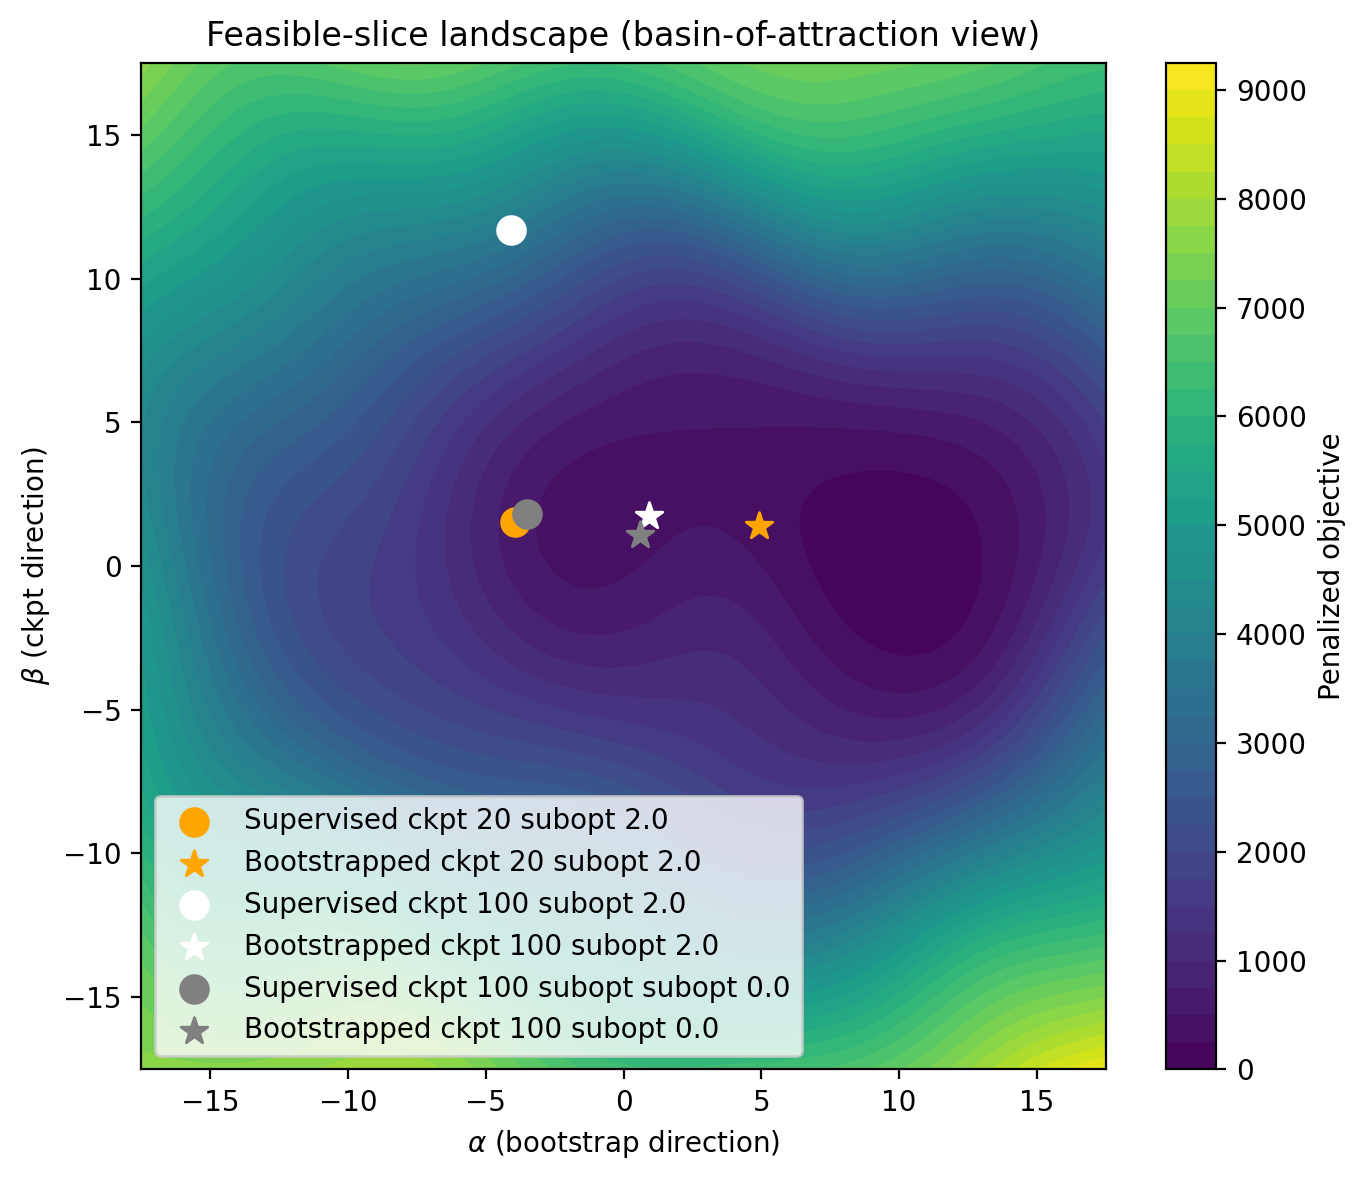

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6), dpi=200)
cs = plt.contourf(AA, BB, Z, levels=40)
plt.colorbar(cs, label="Penalized objective")

plt.scatter(a0, b0, c="orange", s=100, label="Supervised ckpt 20 subopt 2.0")
plt.scatter(a1, b1, c="orange", s=100, marker="*", label="Bootstrapped ckpt 20 subopt 2.0")
plt.scatter(a2, b2, c="white", s=100, label="Supervised ckpt 100 subopt 2.0")
plt.scatter(a3, b3, c="white", s=100, marker="*", label="Bootstrapped ckpt 100 subopt 2.0")
plt.scatter(a4, b4, c="gray", s=100, label="Supervised ckpt 100 subopt subopt 0.0")
plt.scatter(a5, b5, c="gray", s=100, marker="*", label="Bootstrapped ckpt 100 subopt 0.0")

plt.xlabel(r"$\alpha$ (bootstrap direction)")
plt.ylabel(r"$\beta$ (ckpt direction)")
plt.legend()
plt.title("Feasible-slice landscape (basin-of-attraction view)")
plt.tight_layout()
plt.show()